<a href="https://colab.research.google.com/github/sally03915/2026-AI-Analysis-Lab/blob/main/AI-FlowTransformation/Step1-Math/basic003_%EB%94%A5%EB%9F%AC%EB%8B%9D%ED%99%94%EB%A0%A5%EC%A1%B0%EC%A0%88_%EB%AF%B8%EB%B6%84_%EA%B2%BD%EC%82%AC%ED%95%98%EA%B0%95%EB%B2%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 👨‍🍳 데이터 분석 레스토랑: 딥러닝 오븐의 화력 조절법 (미분과 경사하강법)

---

앞서 우리는 **Pandas**로 재료를 썰고, **NumPy** 접시에 담아, **TensorFlow**라는 오븐에 넣는다고 배웠습니다.

그런데 오븐에 넣고 무작정 기다린다고 요리가 맛있어질까요? 아닙니다. 처음 구워보는 요리라면 불이 너무 세서 탈 수도 있고, 너무 약해서 안 익을 수도 있습니다. 요리를 맛있게 완성하려면 **"불을 아주 미세하게 줄이거나 키우면서"** 최적의 화력을 찾아야 합니다. 딥러닝 수학에서 말하는 **미분**과 **경사하강법**이 바로 이 '미세한 불 조절 과정'입니다.






<br/>
<br/>
<br/>

👉👉👉👉👉👉👉👉👉 쉽게 풀어서 설명하면:  
- **미분**은 함수가 얼마나 변하는지, 즉 기울기를 계산하는 방법이에요.  
- **경사하강법**은 이 기울기를 이용해서 “내려가는 방향”으로 조금씩 이동하면서 최적의 값을 찾는 알고리즘이에요.  
- 딥러닝에서는 **손실 함수(loss function)** 라는 걸 최소화해야 하는데, 경사하강법을 이용해 가중치(weight)를 계속 조정하면서 손실을 줄여 나가는 거죠.  

예를 들어:  
1. 현재 위치에서 기울기를 계산한다.  
2. 기울기가 양수면 왼쪽으로, 음수면 오른쪽으로 이동한다.  
3. 이동할 때는 너무 크게 움직이지 않도록 **학습률(learning rate)** 이라는 작은 값만큼만 조정한다.  
4. 이 과정을 반복하면 결국 “최저점(최적값)”에 도달한다.  

💡 비유: 산 위에서 공을 굴리면 공은 경사가 가장 가파른 방향으로 굴러 내려가죠. 경사하강법도 똑같이 “내려가는 길”을 따라가면서 최저점을 찾는 방법이에요.






#### 1. 지수 함수 $e^x$
- **뜻:** “어떤 수 $e$를 x번 곱한다”는 의미예요.  
- $e$는 약 **<mark>$2.718\dots$</mark>** 이라는 특별한 수입니다.  
- 예:   
  - $e^1 = e \approx 2.718 \to e$를 $1$번 곱한 값  
  - $e^2 = e \times e \approx 7.389 \to e$를 $2$번 곱한 값  
-
- **비유:** 돈이 이자로 불어나는 과정처럼, 시간이 지날수록 값이 커지는 걸 표현합니다.  

#### 2. 로그 함수 $\ln(x)$
- **뜻:** “$e$를 몇 번 곱해야 x가 되느냐”를 알려주는 함수예요.  
- 예:  
  - $\ln(e) = 1$  
    $\to e^1 = e \approx 2.718$  
    $\to$ “$2.718$이라는 값은 $e$를 $1$번 곱했을 때 나온 결과”  
  - $\ln(e^2) = 2$  
    $\to e^2 = e \times e \approx 7.389$  
    $\to$ “$7.389$이라는 값은 $e$를 $2$번 곱했을 때 나온 결과”  
  - $\ln(e^3) = 3$  
    $\to e^3 = e \times e \times e \approx 20.085$  
    $\to$ “$20.085$이라는 값은 $e$를 $3$번 곱했을 때 나온 결과”  


- **비유:** 커진 양을 보고 “이만큼 커지려면 시간이 얼마나 걸렸을까?”를 알려줍니다.  

#### 3. 서로 반대 개념
- $e^x$: 시간을 넣으면 커진 양을 알려줌  
- $\ln(x)$: 커진 양을 넣으면 걸린 시간을 알려줌  
- 즉, **지수와 로그는 서로 거꾸로 된 함수**입니다.  

```python
import math

x = 2
print("e^x:", math.exp(x))   # e^2 \u2248 7.39
print("ln(e^x):", math.log(math.exp(x)))  # ln(e^2) = 2
```

🦍 딥러닝에서의 역할 (1):
`e^x` (지수함수)는 모델이 받은 정보를 '활성화'시켜 다음 단계로 전달할 때, 너무 강하거나 약하지 않게 ***부드럽게 조절***해서 '**중요한 신호**'를 만들어주는 스위치 역할을 해요. `ln(x)` (자연로그)는 모델이 '**확률**' 같은 작은 숫자들을 다룰 때, **계산 오류 없이** ***정확하게 비교***할 수 있게 돕는 '**정밀 분석 도구**'입니다.

🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
`e^x`는 노래방에서 마이크 볼륨을 키우는데, '소리를 **너무 깨지지 않게 부드럽게 키워주는**' **자동 볼륨 조절기** 같아요. `ln(x)`는 아주 작은 소리도 놓치지 않고 '**정확히 듣고 분석하는**' **특수 이어폰**과 같습니다.

🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
셰프가 '재료의 향'을 최적화할 때, `e^x`는 향이 ***자연스럽게 퍼지도록*** 돕는 '**향기 확산기**'이고, `ln(x)`는 미세한 향의 차이도 ***정확히 감지***해서 '**완벽한 조화**'를 찾아주는 '**향기 감별사**' 같은 역할이에요.

<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>


### **1. 미분: "불을 아주 살짝 바꾸면, 요리 상태는 얼마나 바뀔까?" ⚡**

복잡한 수식이 나오지만, 본질은 아주 단순합니다.

* **미분이란?** 어떤 원인($x$)을 **아주 미세하게 변화시켰을 때**, 결과($y$)가 얼마나 민감하게 반응하는지(변화량)를 나타내는 지표입니다. 그래프에서는 그 순간의 '기울기(접선)'로 나타납니다.
* **레스토랑 비유:** 가스레인지 다이얼($x$)을 오른쪽으로 **0.1도 아주 살짝 돌렸을 때**, 오븐의 온도($y$)가 얼마나 확 올라가는지 그 **민감도**를 측정하는 것입니다.

> **💡 어려운 수식 먼저 쉽게 해독하기!**
> 영어가 섞인 수학 기호들, 지레겁먹으실 필요 전혀 없습니다! 주방용어로 번역해 드릴게요.
> * $\Delta x$ (델타 엑스) $\rightarrow$ **"가스레인지 다이얼을 아주 미세하게 까딱인 정도"**
> * $\Delta y$ (델타 와이) $\rightarrow$ **"그 결과 오븐 온도가 변화한 정도"**
> * $\frac{\Delta y}{\Delta x}$ $\rightarrow$ **"다이얼 조절 대비 온도 변화율(기울기)"**
> * $\lim_{\Delta x \to 0}$ (리미트...) $\rightarrow$ **"0에 가깝게 정말 초미세하게 조절하겠다!"**
>
>

여기까지 이해하셨다면, 수학 공식이 아니라 "초미세 불 조절의 정의"를 말하고 있다는 것을 쉽게 알 수 있습니다!

#### 🧑‍🍳 딥러닝에서의 미분: '불 조절 민감도'로 배우는 셰프의 감각

딥러닝에서는 이 '민감도'를 **모델의 파라미터(가중치와 편향)** 에 적용합니다. 모델의 파라미터를 아주 조금 바꿨을 때, 예측 결과의 **'오차(탄 맛)'** 가 얼마나 변하는지 미분을 통해 계산합니다. 이 민감도를 알아야만 딥러닝 모델이 '이번엔 불을 좀 더 세게 해야 할까, 약하게 해야 할까?'를 결정할 수 있게 됩니다.

🦍 딥러닝에서의 역할 (1):
미분은 모델이 어떤 재료(파라미터)를 **얼마나 많이** 혹은 **얼마나 적게** 바꿔야 요리의 맛(예측 오차)이 가장 효율적으로 좋아질지 알려주는 '**정밀 계측기**' 같은 역할을 해요.

🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
셰프가 스테이크를 굽는데, 불 온도를 1도 올리면 스테이크가 얼마나 빨리 탈지, 혹은 1도 내리면 얼마나 천천히 익을지 알아야 최적의 온도를 찾겠죠? 미분은 이런 '**1도 변화**'에 대한 '**맛의 민감도**'를 알려줍니다.

🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
아이가 블록 쌓기 게임을 하는데, 어떤 블록 하나를 살짝 옮겼을 때 전체 탑이 무너질 듯 위태로워지는지(민감도가 높음), 아니면 끄떡없는지를 파악하는 것과 같아요. 모델은 미분으로 **중요한 블록**을 찾아 섬세하게 다룹니다.


<br/>
<br/>
<br/>
<br/>

수학자들은 이 초미세 변화율을 매번 길게 쓰기 귀찮아서 아래처럼 $f'(x)$ 또는 $\frac{df}{dx}$ 같은 약속된 기호(미분 기호)로 줄여서 쓰기로 했습니다. 기호의 모양만 다를 뿐, 전부 "화력 조절 민감도"를 뜻하는 말입니다.



**다항함수의 미분 공식**

$$f(x) = x^2 \implies f'(x) = 2x$$

<br/>
<br/>

### 💡 미분의 원래 의미: "순간적인 변화율"

미분한다는 것은 그래프 위의 한 점에서 기울기(변화율)를 구하는 것입니다.
기울기를 구하려면 원래 두 점이 필요하죠? 그래서 $x$라는 점과, 거기서 아주 조금($h$만큼) 떨어진 $x+h$라는 두 점을 잡고 시작합니다.

두 점의 평균 기울기는 다음과 같이 구합니다.


$$\text{기울기} = \frac{\text{y의 변화량}}{\text{x의 변화량}} = \frac{f(x+h) - f(x)}{(x+h) - x} = \frac{f(x+h) - f(x)}{h}$$

여기서 $h$를 **0에 아주 가깝게 붙여버리면($h \to 0$)** 두 점이 마치 한 점처럼 겹치면서 그 순간의 기울기($f'(x)$)가 됩니다.


<br/>
<br/>

### 🛠️ 직접 계산해보기 ($f(x) = x^2$ 대입)

이제 우리가 궁금한 $f(x) = x^2$을 위 식에 그대로 넣어보겠습니다.

1. **공식에 대입하기**

. $\lim_{h \to 0}$의 진짜 의미

> **"지금부터 $h$ 자리에 0을 집어넣을 건데, 그전에 식 정리부터 좀 하자!"** 라는 뜻입니다.

곧바로 $h$에 0을 넣을 수 있으면 참 좋을 텐데, 미분 공식 처음 부분을 보면 분모에 $h$가 있죠? 수학에서는 분모가 0이 되는 것을 허용하지 않기 때문에, **처음부터 0을 넣으면 계산이 안 됩니다.**



$$f'(x) = \lim_{h \to 0} \frac{(x+h)^2 - x^2}{h}$$

<br/>
<br/>
<br/>

2. **분자 전개하기**
$(x+h)^2$을 전개하면 $x^2 + 2xh + h^2$이 됩니다.

$$f'(x) = \lim_{h \to 0} \frac{(x^2 + 2xh + h^2) - x^2}{h}$$

<br/>
<br/>
<br/>

3. **분자 정리하기 ($x^2$ 지우기)**
분자의 $x^2$과 $-x^2$이 서로 사라집니다.

$$f'(x) = \lim_{h \to 0} \frac{2xh + h^2}{h}$$


<br/>
<br/>
<br/>

4. **분모의 $h$로 약분하기**
분자와 분모에 모두 있는 $h$를 나누어줍니다.

$$f'(x) = \lim_{h \to 0} (2x + h)$$


<br/>
<br/>
<br/>

5. **$h$를 0으로 보내기**
이제 $h$에 0을 대입해도 분모가 0이 되는 문제가 없으니, 안심하고 $h$ 자리에 0을 넣습니다.

$$f'(x) = 2x + 0 = 2x$$




In [ ]:
# 🧑‍🍳 사칙연산 버전
# 비유: “불 조절 다이얼” → 다이얼을 조금 돌렸을 때 불이 얼마나 세게 변하는지.
# 개념:  함수 -  f(x)=x²,   미분공식- f'(x)=2x

x = 3
y = x**2   # f(x) = x^2
slope = 2*x   # 기울기 계산 (사칙연산만)
print("x:", x, "y:", y, "slope:", slope)

# 👉 출력: x=3일 때 y=9, slope=6 → “불을 조금 돌리면 세기가 6만큼 변한다”


x: 3 y: 9 slope: 6


Derivative result: 2*x
Slope at x=3: 6


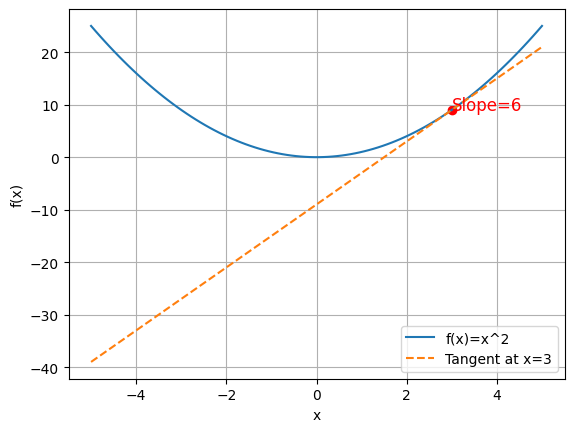

In [ ]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

# 함수와 미분 정의
x = sp.Symbol('x')          # x를 수학적 기호(symbol)로 정의
f = x**2                    # 함수 f(x) = x^2 정의
df = sp.diff(f, x)          # f(x)를 x에 대해 미분 → 결과는 2*x

# 특정 값에서 기울기 계산
x_value = 3                 # 기울기를 확인할 x 값
slope = df.subs(x, x_value) # df 식에 x=3을 대입해서 기울기 계산
y_value = f.subs(x, x_value)# f(x)에서 x=3일 때 y 값 계산

print("Derivative result:", df)
print(f"Slope at x={x_value}:", slope)

# 그래프 그리기
x_vals = np.linspace(-5, 5, 100)     # -5부터 5까지 100개 점 생성
y_vals = [val**2 for val in x_vals]  # 각 점에 대해 f(x)=x^2 계산

plt.plot(x_vals, y_vals, label="f(x)=x^2")  # 함수 그래프 그리기

# 접선 그리기: y = slope*(x - x_value) + y_value
tangent_line = slope*(x_vals - x_value) + y_value
plt.plot(x_vals, tangent_line, '--', label=f"Tangent at x={x_value}")

# 점 표시
plt.scatter([x_value], [y_value], color='red')   # 접점 표시
plt.text(x_value, y_value, f"Slope={slope}", fontsize=12, color='red') # 기울기 표시

# 축과 기타 설정
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


이 결과는 `x`가 `3`일 때, 함수 `f(x) = x^2`의 기울기가 `6`이라는 의미입니다. 우리 비유로 설명하자면:

*   **가스 스토브 다이얼 `x`가 `3`을 가리키고 있을 때, 다이얼을 아주 미세하게 돌리면 오븐 온도가 `6`만큼의 민감도로 변화한다**는 뜻입니다.

즉, `x`가 커질수록(다이얼을 더 많이 돌릴수록) 온도 변화에 대한 민감도도 커지는 것을 확인할 수 있습니다. `x=3`일 때의 '화력 조절 민감도'가 `6`이라는 거죠.

---

### 💡 확인 문제: 1. 미분 (Differentiation)

Q1. 딥러닝에서 '미분'은 가스레인지 다이얼($x$)을 아주 미세하게 돌렸을 때 오븐 온도($y$)가 얼마나 민감하게 변하는지 나타내는 \[ ]를 계산하는 것입니다.

Q2. 딥러닝 모델은 미분을 통해 파라미터(가중치)를 변경했을 때 손실(오차)이 얼마나 민감하게 변하는지 파악하여 다음 학습 방향을 결정한다. (O/X)

Q3. 오븐 온도의 변화를 나타내는 함수 $f(x) = x^2$이 있다고 합시다. 현재 가스레인지 다이얼 `x`가 `5`를 가리키고 있을 때, 다이얼을 미세하게 조절했을 때의 온도 변화 민감도(기울기)는 얼마일까요? (단, $f'(x) = 2x$를 사용하세요.)




<br/><br/><br/>
✅ 정답

Q1. 기울기(변화율)

Q2. O

Q3. $f'(x) = 2x$ 이므로, $f'(5) = 2 \times 5 = 10$. 기울기는 10입니다.

<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>

### **2. 경사하강법(Gradient Descent): 최고의 맛을 찾는 눈먼 셰프 🏔️**

다이얼을 쥐고 있는 그 순간의 기울기(미분값)를 계산했을 때, 우리는 불을 켜야 할지 꺼야 할지 방향을 알 수 있습니다.

* **기울기가 플러스(+)라면?** 다이얼을 오른쪽으로 돌릴 때(증가) 오븐 온도도 올라간다(증가)는 뜻입니다. 그래프가 오른쪽 위를 향합니다.
* **기울기가 마이너스(-)라면?** 다이얼을 오른쪽으로 돌릴 때 오히려 온도가 떨어진다는 뜻입니다. 그래프가 오른쪽 아래를 향합니다.

이 성질을 이용하면 그래프 위의 어떤 위치에 있더라도 내가 어느 방향으로 움직여야 하는지 방향을 잡을 수 있습니다. 아래 이미지의 곡선 위에서 점들이 움직이며 기울기(선)의 각도가 어떻게 변하는지 눈으로 가볍게 따라가 보세요.


딥러닝의 최종 목적은 '오차(탄 맛)'를 최소(0)로 만드는 최적의 타이밍을 찾는 것입니다.

우리가 안개가 가득 찬 산속(오차 그래프)에 서 있다고 해봅시다. 어디가 제일 아래쪽(오차가 최소인 평지)인지 눈으로는 보이지 않습니다. 이때 우리는 발바닥 끝으로 **지금 딛고 있는 땅의 기울기**를 느끼며 한 걸음씩 내려갑니다.

* 땅이 앞으로 내리막길(-)이면? 앞으로 한 발자국 걸어 내려갑니다.
* 땅이 앞으로 오르막길(+)이면? 뒤로 한 발자국 물러섭니다.

이것을 수학적으로 표현한 것이 바로 아래의 **경사하강법** 공식과 그래프입니다. 기울기가 0이 되는 골짜기 밑바닥을 향해 점이 점차 이동하는 모습이 보이시나요?


#### 🧑‍🍳 딥러닝에서의 기울기 부호: '오차를 줄이는 방향' 찾기

딥러닝 모델은 이 **기울기의 부호**를 보고 파라미터(가스레인지 다이얼)를 어느 방향으로 움직여야 오차(탄 맛)를 줄일 수 있을지 결정합니다.

*   기울기가 양수(+)면: 현재 다이얼을 '오른쪽으로' 돌리면 오차가 더 커진다는 뜻이므로, 다이얼을 '왼쪽으로' 돌려야 합니다.
*   기울기가 음수(-)면: 현재 다이얼을 '오른쪽으로' 돌리면 오차가 줄어든다는 뜻이므로, 다이얼을 '오른쪽으로' 돌려야 합니다.

이렇게 모델은 **기울기 부호의 반대 방향**으로 파라미터를 조금씩 조정하며 최적의 값을 찾아갑니다.

🦍 딥러닝에서의 역할 (1):
기울기의 부호는 모델에게 '오차(요리의 맛없음)를 줄이려면 지금 이 파라미터(재료 양)를 **늘려야 할지, 줄여야 할지**'를 즉시 알려주는 '**YES/NO 버튼**'과 같아요.

🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
어두운 방에서 벽 스위치를 찾는데, 오른쪽으로 손을 뻗었더니 더 어두워지는 느낌(기울기 양수)이 들면 '아, **왼쪽으로 가야 밝아지는구나**' 하고 반대 방향으로 가는 것과 같습니다. **부호가 방향**을 알려주는 거죠.

🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
주방에서 요리하는데 '소금 좀 더 넣을까 말까?' 고민될 때, 요리책이 '**지금은 소금 부족! 더 넣어라(+)**' 또는 '**지금 소금 과다! 빼라(-)**'고 **명확히 지시**해주는 것과 같아요.

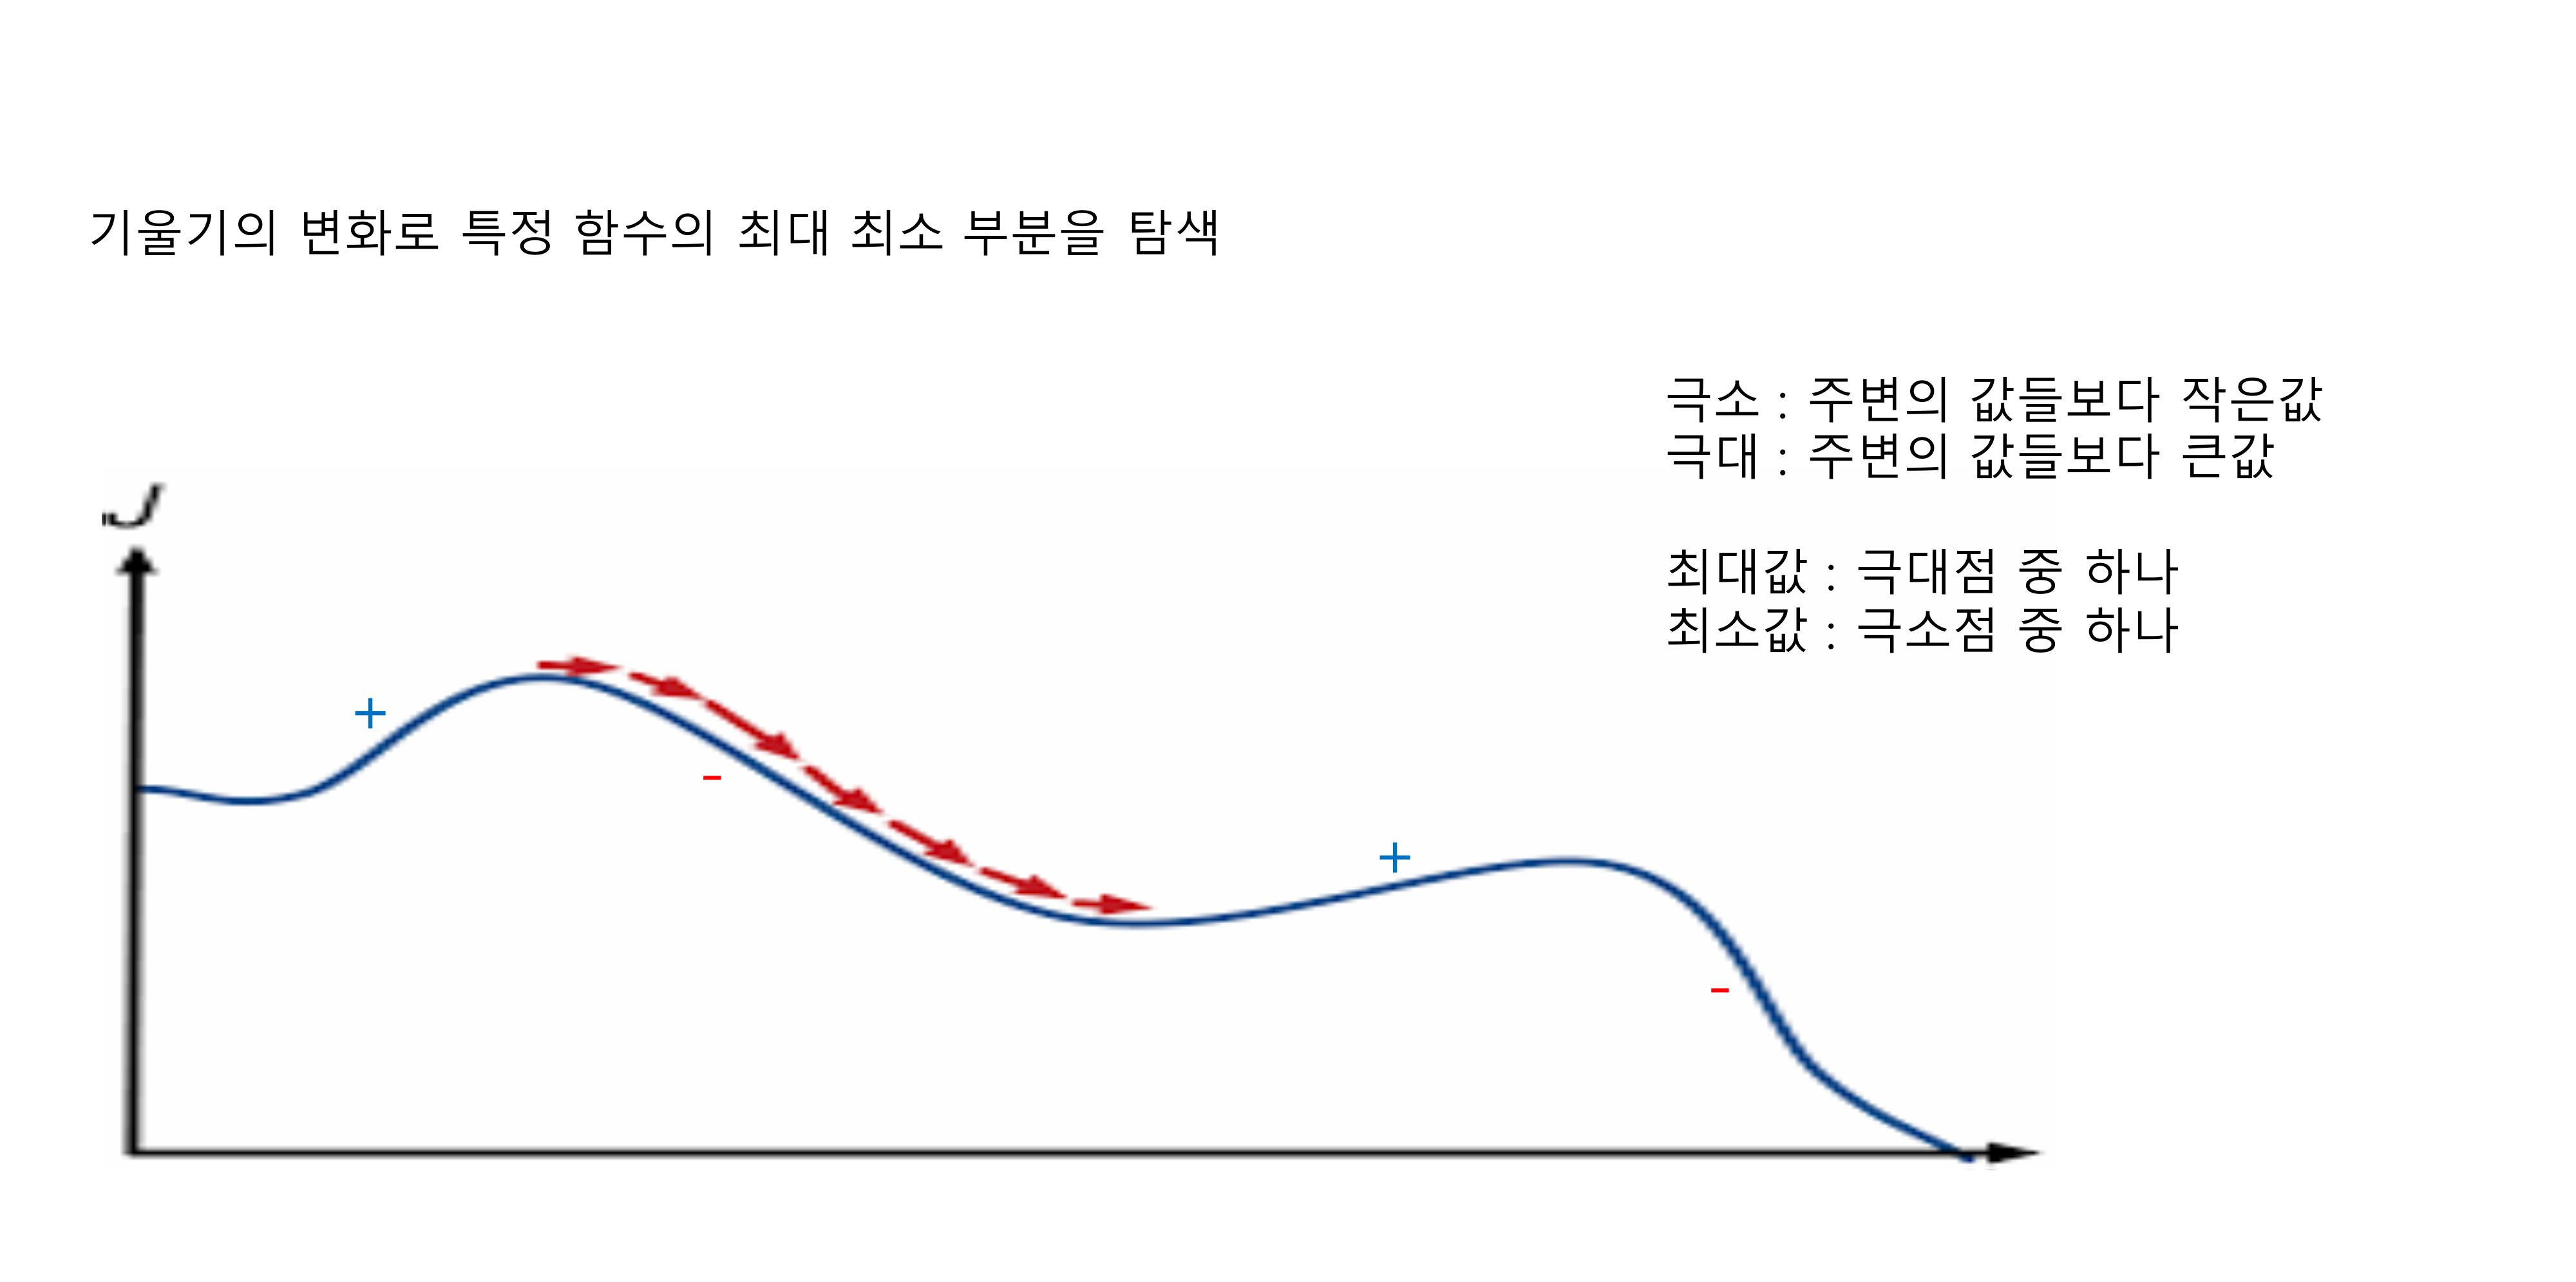

#### ① 미분 기호 ($ \Delta y / \Delta x $, $ f'(x) $)를 보았을 때

* **어떻게 해석해?** ➔ "가스레인지 불을 **0.1도 아주 미세하게 까딱(x)** 했을 때, **오븐 온도(y)가 얼마나 예민하게 반응하는가?**"를 나타내는 '민감도 다이얼'입니다.
* **수식 외워야 해?** ➔ 아니요! 마지막 퀴즈 정답처럼 TensorFlow(보조 셰프)가 알아서 계산하므로, 우리는 "이게 불 조절 민감도구나"라고 이해만 하면 끝입니다.

#### ② 기울기의 부호 ($+$ 또는 $-$)를 보았을 때

* **그래프가 오른쪽 위로 올라감 ($+$):** "아, 지금 다이얼을 오른쪽으로 돌리면 불이 더 세지는구나!"
* **그래프가 오른쪽 아래로 내려감 ($-$):** "아, 지금 다이얼을 오른쪽으로 돌리면 불이 꺼지는구나!"
* **이걸로 뭘 해?** ➔ 컴퓨터는 이 부호를 보고 불을 켤지 끄고 줄일지(방향)를 결정합니다.




실제 인공지능 모델은 화력 조절 다이얼이 수백, 수만 개가 넘습니다. 이를 가중치($W$, $b$)라고 부르는데, 컴퓨터는 이 수많은 다이얼들의 미분값을 동시에 계산하면서 오차가 가장 적은 3차원 공간의 웅덩이를 향해 미끄러져 내려갑니다. 이것이 바로 인공지능의 '학습'입니다.

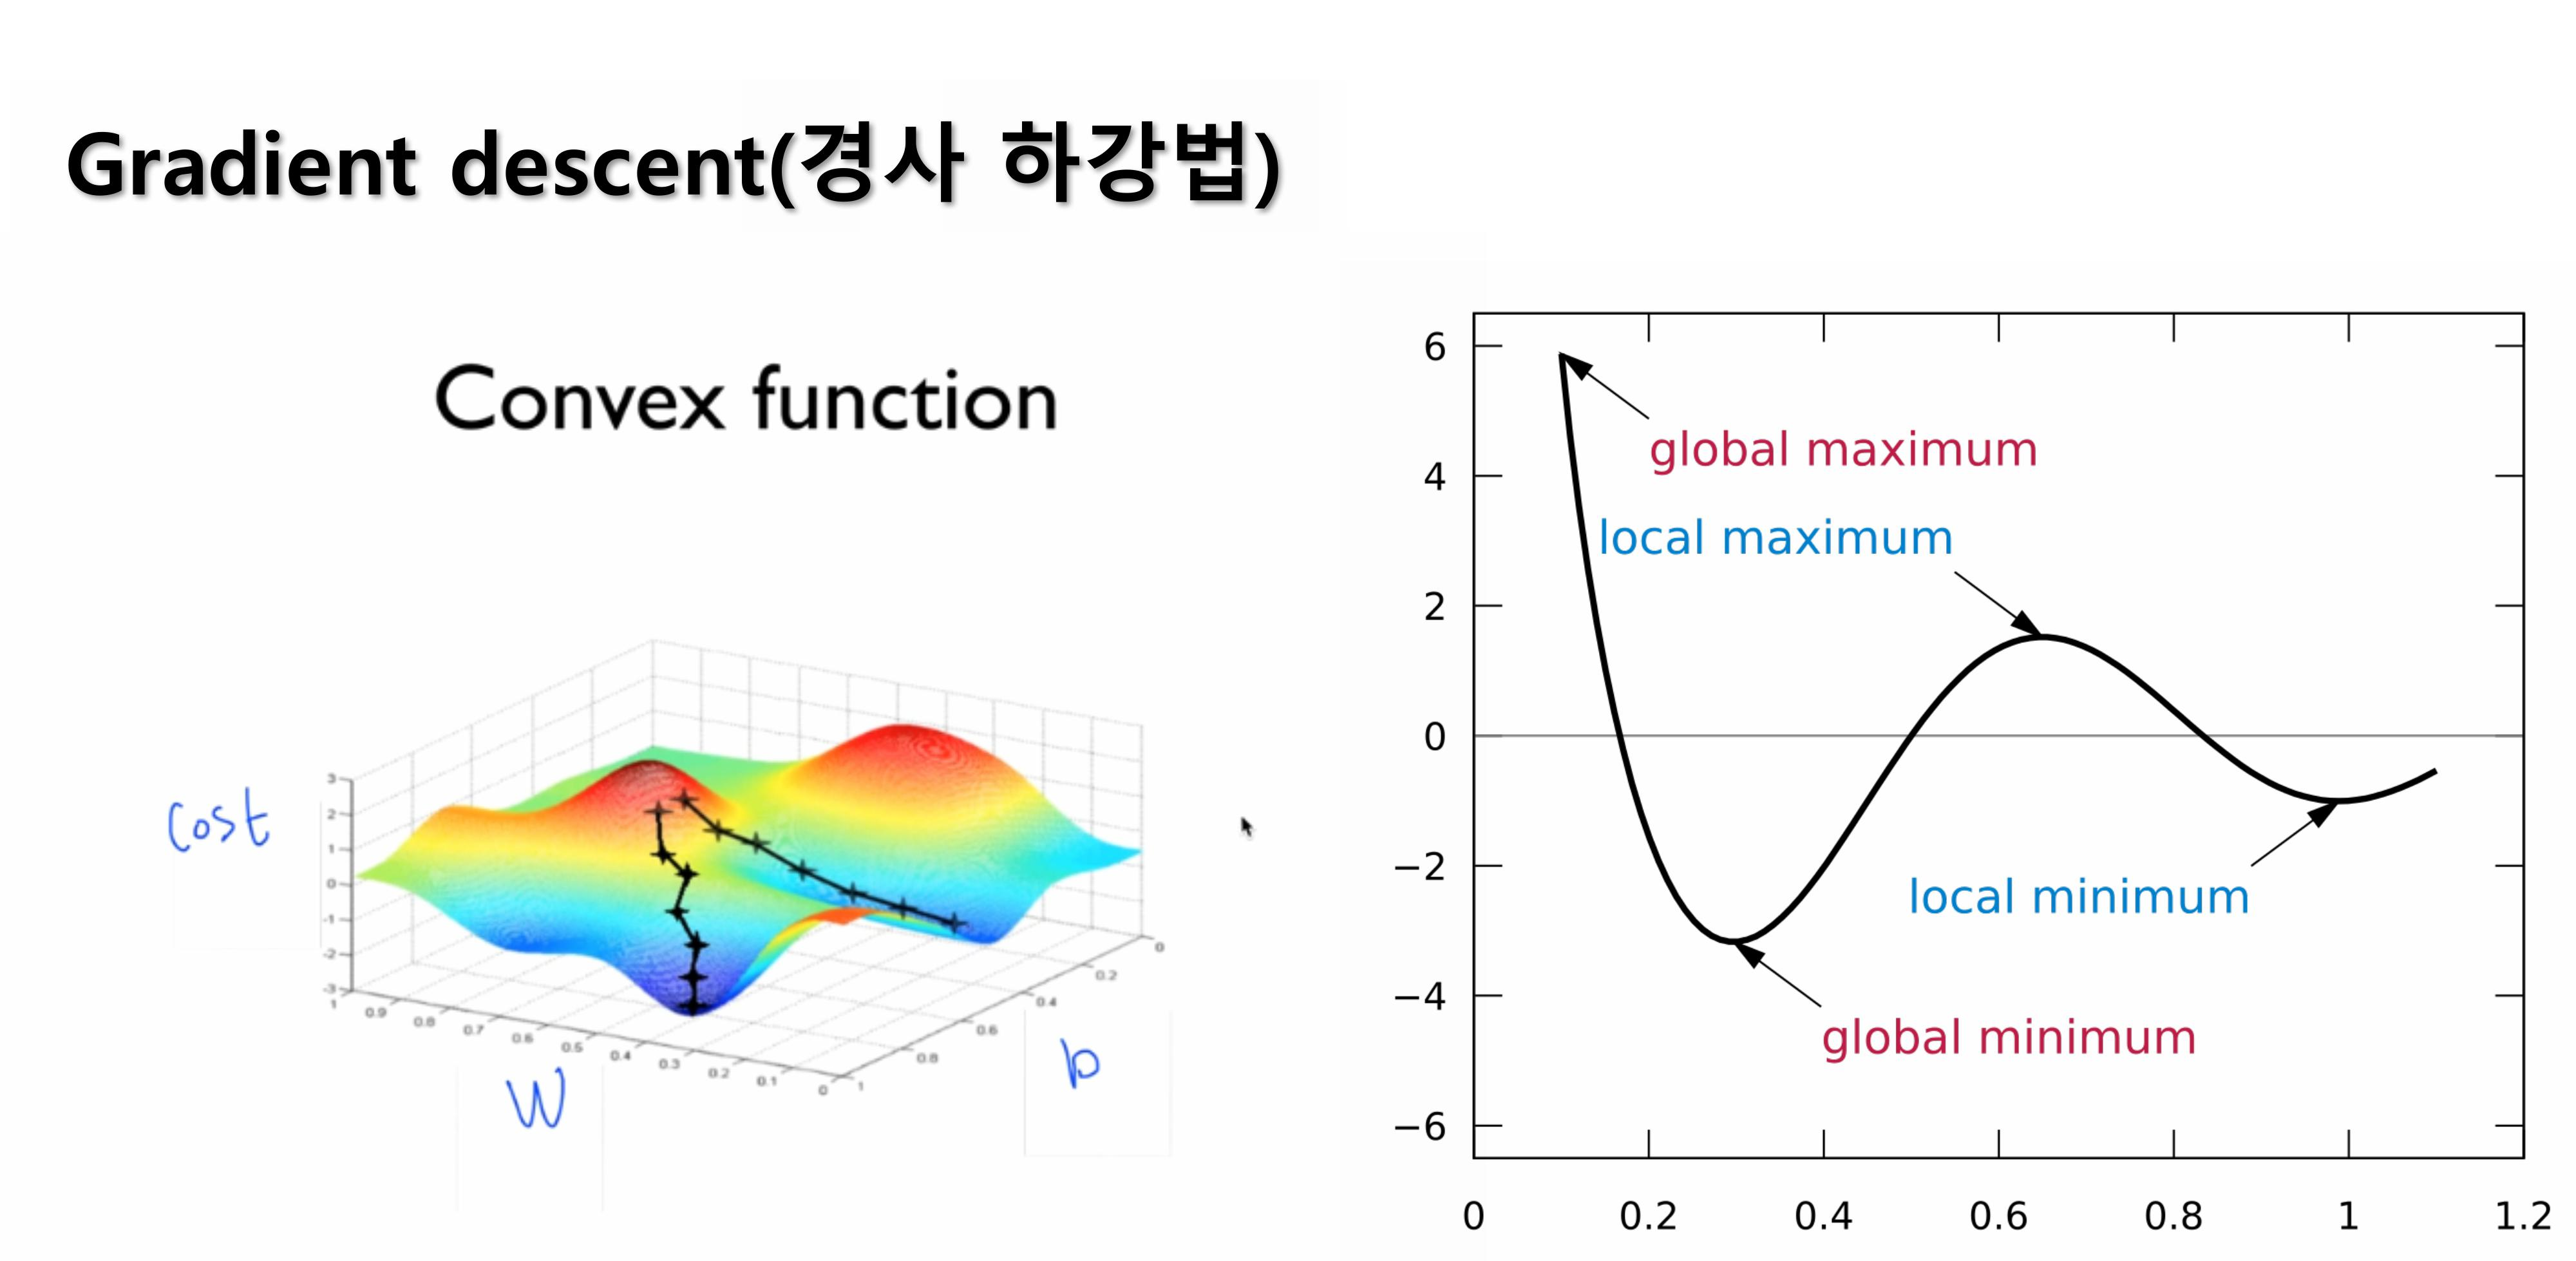

#### ③ 경사하강법 그래프 를 보았을 때

* **어디를 봐?** ➔ U자 모양의 '골짜기 맨 밑바닥(기울기가 0인 평지)'을 보세요.
* **곡선이 어떻게 되는데?** ➔ 점이 경사를 따라 밑으로 점점 미끄러져 내려갑니다.
* **이게 뭘 의미해?** ➔ "오차(탄 맛)가 0에 가까워지는 가장 완벽한 상태"를 찾아가는 과정입니다. 이 바닥에 도착하는 순간이 인공지능 학습 완성이자 최고의 요리가 탄생하는 순간입니다.

#### 🧑‍🍳 딥러닝에서의 경사하강법 그래프 해석: '최고의 요리'를 향한 학습 과정

이 그래프에서 **U자 곡선**은 X축(모델의 파라미터) 값에 따라 Y축(오차 값)이 어떻게 변하는지를 보여줍니다. 목표는 Y축 값이 가장 낮은, 즉 **'오차가 최소가 되는 지점'** 을 찾는 것입니다.

*   **그래프 위에서 점들이 움직이는 것:** 딥러닝 모델이 학습을 진행하면서 **파라미터(가중치와 편향) 값을 반복적으로 업데이트**하는 과정을 시각화한 것입니다.
*   **점들이 골짜기 밑으로 내려가는 것:** 매 단계마다 **미분을 통해 현재 위치의 기울기를 계산**하고, 그 기울기의 반대 방향(오차가 줄어드는 방향)으로 파라미터 값을 조정합니다. 이렇게 한 걸음씩 오차의 골짜기 아래로 내려가면서 점점 더 정확한 모델로 '학습'해 나가는 것입니다.
*   **골짜기 맨 밑바닥:** 이 지점에 도달하면 모델의 오차가 최소화되어 **최적의 성능**을 가지게 됩니다. 마치 최고의 레시피와 불 조절 감각을 익힌 셰프가 완벽한 요리를 만들어내는 것과 같습니다.

🦍 딥러닝에서의 역할 (1):
경사하강법 그래프는 딥러닝 모델이 '**가장 맛있는 요리 레시피(최적의 파라미터)**'를 찾아가는 과정을 눈으로 볼 수 있게 해주는 '**요리 과정 일지**'예요. 모델이 **잘 배우고 있는지** 한눈에 보여주죠.

🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
보물찾기 게임을 하는데, 지도가 "지금 네 위치에서 보물은 저 아래쪽으로 가면 돼!" 하고 방향을 알려주면, 그 방향으로 한 걸음씩 움직여 **보물(최소 오차)**을 찾는 것과 같아요. 이 그래프는 보물을 찾아가는 **발자취**입니다.

🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
처음 요리를 배우는 학생이 수십 번 연습해서 점점 맛있는 음식을 만들어내는 '**실력 향상 그래프**'와 같습니다. 매번 맛을 보고 피드백(기울기)을 받아 다음 요리에 반영하며 **발전하는 과정**을 보여줍니다.

In [ ]:
# 🧑‍🍳 사칙연산 버전
# 비유: “정답 맞추기 게임” → 답을 조금씩 고쳐서 정답에 가까워짐.
# loss가 0에 제일로 가까운것 찾기

w = 5   # 처음 - 틀린답
learning_rate = 0.1   # 한 번에 답을 얼마나 고칠지 정하는 값

# “틀린 정도”를 계산하는 함수 -
def loss(w):
    return (w-3)**2   ##  답정해둠 :  (w-3)  w가 3일 때 (w-3)=0 → loss=0 → 가장 작은 값(최소값).

def update(w):
    if w > 3:
        w = w - learning_rate  # 답이 너무 크면 조금 줄이기
    else:
        w = w + learning_rate  #  답이 너무 작으면 조금 늘리기
    return w

for i in range(20):
    w = update(w)
    print(f"Step {i+1}: w={w:.2f}, loss={loss(w):.2f}")

# 👉 출력: w가 점점 3에 가까워지고 loss가 줄어듦
# 📐 수학 버전
# 개념: w ← w - α·∇loss(w)
# 코드: (dloss(w)=2*(w-3) 사용)
# 그래프: 빨간 점들이 점점 (3,0)으로 수렴하는 모습

Step 1: w=4.90, loss=3.61
Step 2: w=4.80, loss=3.24
Step 3: w=4.70, loss=2.89
Step 4: w=4.60, loss=2.56
Step 5: w=4.50, loss=2.25
Step 6: w=4.40, loss=1.96
Step 7: w=4.30, loss=1.69
Step 8: w=4.20, loss=1.44
Step 9: w=4.10, loss=1.21
Step 10: w=4.00, loss=1.00
Step 11: w=3.90, loss=0.81
Step 12: w=3.80, loss=0.64
Step 13: w=3.70, loss=0.49
Step 14: w=3.60, loss=0.36
Step 15: w=3.50, loss=0.25
Step 16: w=3.40, loss=0.16
Step 17: w=3.30, loss=0.09
Step 18: w=3.20, loss=0.04
Step 19: w=3.10, loss=0.01
Step 20: w=3.00, loss=0.00


Step 1: x=4.0000, f(x)=16.0000
Step 2: x=3.2000, f(x)=10.2400
Step 3: x=2.5600, f(x)=6.5536
Step 4: x=2.0480, f(x)=4.1943
Step 5: x=1.6384, f(x)=2.6844
Step 6: x=1.3107, f(x)=1.7180
Step 7: x=1.0486, f(x)=1.0995
Step 8: x=0.8389, f(x)=0.7037
Step 9: x=0.6711, f(x)=0.4504
Step 10: x=0.5369, f(x)=0.2882
Step 11: x=0.4295, f(x)=0.1845
Step 12: x=0.3436, f(x)=0.1181
Step 13: x=0.2749, f(x)=0.0756
Step 14: x=0.2199, f(x)=0.0484
Step 15: x=0.1759, f(x)=0.0309
Step 16: x=0.1407, f(x)=0.0198
Step 17: x=0.1126, f(x)=0.0127
Step 18: x=0.0901, f(x)=0.0081
Step 19: x=0.0721, f(x)=0.0052
Step 20: x=0.0576, f(x)=0.0033


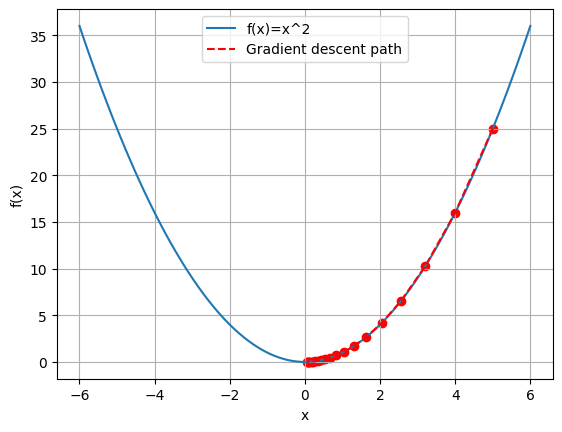

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 최소화하려는 함수와 그 미분
def f(x):
    return x**2   # 함수 f(x)=x^2   - x=0일 때 가장 작은 값(0)

def df(x):
    return 2*x    # f(x)의 미분

# 초기값과 학습률 설정
x = 5.0           # 출발점은 x=5에서 시작
learning_rate = 0.1   # 한 번에 얼마나 이동할지(학습률)를 0.1로 설

# 기록용 리스트
x_history = [x]
y_history = [f(x)]

# 10번 반복
# x = x - learning_rate * df(x)   # 기울기 방향으로 이동
#     df(x) → 현재 위치에서의 기울기(경사).
#     learning_rate * df(x) → 한 번에 얼마나 이동할지(기울기 × 학습률).
#     x - ... → 기울기가 양수면 왼쪽(작은 값)으로, 음수면 오른쪽(큰 값)으로 이동.
#     즉, 현재 위치에서 기울기를 따라 조금씩 내려가는 과정
# x = 5 - 0.1*10 = 4.0 → f(x)=16

for i in range(20):
    x = x - learning_rate * df(x)   # 기울기 방향으로 이동
    x_history.append(x)
    y_history.append(f(x))
    print(f"Step {i+1}: x={x:.4f}, f(x)={f(x):.4f}")

# 그래프 시각화
x_vals = np.linspace(-6, 6, 100)
y_vals = f(x_vals)

plt.plot(x_vals, y_vals, label="f(x)=x^2")
plt.scatter(x_history, y_history, color='red')  # 이동 경로 표시
plt.plot(x_history, y_history, '--', color='red', label="Gradient descent path")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()



### 📊 결과 해석
- 빨간 점들이 점점 `(0,0)`으로 내려가는 모습이 보입니다.  
- 처음엔 `x=5`에서 시작해 `f(x)=25`였지만, 반복할수록 `x`가 0에 가까워지고 `f(x)`도 줄어듭니다.  
- 즉, 공이 산 아래로 굴러가듯이 함수의 최저점에 도달하는 과정이 눈에 보입니다.  


---

### 💡 확인 문제: 2. 경사하강법 (Gradient Descent)

Q1. 경사하강법은 손실 함수의 \[ ]를 따라 이동하며 오차(손실)를 최소화하는 파라미터 값을 찾는 알고리즘입니다.

Q2. 딥러닝 모델은 경사하강법을 사용하여 계산된 기울기의 방향과 동일한 방향으로 파라미터(가중치)를 업데이트하여 손실을 줄여나간다. (O/X)

Q3. 안개 낀 산속에서 눈먼 셰프가 발바닥으로 땅의 기울기를 느끼며 가장 낮은 평지(최소 오차 지점)를 찾아 내려가는 과정은 딥러닝의 어떤 학습 방법을 비유한 것일까요?

Q4. 경사하강법에서 `학습률(learning rate)`이 너무 크면 어떤 문제가 발생할 수 있으며, 그 역할은 무엇일까요?




<br/><br/><br/>
✅ 정답

Q1. 기울기(경사)

Q2. X. 기울기의 **반대** 방향으로 업데이트합니다. (기울기가 양수면 감소, 음수면 증가)

Q3. 경사하강법 (Gradient Descent)

Q4. 학습률이 너무 크면 최저점을 지나쳐 버리거나(overshoot) 발산하여 최적화에 실패할 수 있습니다. 학습률은 파라미터 업데이트 시 한 번에 이동하는 보폭(step size)을 결정하는 역할을 합니다.

<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>


### **3. 자연상수 $e$와 로그($\ln$): 미세 조절을 위한 마법의 계량 도구 🧪**

특이한 기호들은 컴퓨터가 그래프를 더 부드럽고 계산하기 편하게 다룰 수 있도록 주방에 도입한 '특수 계량컵'입니다.

- **자연상수 \(e\)** 는 “성장이 멈추지 않고 계속되는 과정”을 나타내는 특별한 숫자예요.  
  예를 들어, 은행에 돈을 넣었을 때 이자가 계속 붙는 상황을 생각하면 됩니다.  
- **로그(log)** 는 “성장이 얼마나 오래 걸렸는지”를 알려주는 도구예요.  
  즉, (\(e^x\))는 “시간이 지나면서 커지는 양”,\(e\) 는 “그 크기에 도달하기까지 걸린 시간”을 의미합니다.  

🦍 딥러닝에서의 역할 (1):
자연상수 `e`와 로그 `ln`은 딥러닝 모델이 아주 복잡한 성장 패턴(데이터의 확률 분포)을 **더 자연스럽고 부드럽게** 다루고, **큰 숫자를 작게 압축**해서 **계산 실수 없이** 처리하게 돕는 '**특별한 수학 도구**'입니다.

🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
'e'는 씨앗이 계속 자라 나무가 되는 것처럼 '**멈추지 않는 자연스러운 성장**'을 표현하는 **마법 약** 같아요. 'ln'은 그 나무가 **얼마나 빨리 자랐는지**, 또는 **얼마나 오래 걸렸는지를 정확하게 재는** '**성장 기록계**'와 같습니다.

🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
셰프가 수십 년간의 요리 경험을 바탕으로 '감으로' 재료를 넣듯, `e`와 `ln`은 데이터의 '**자연스러운 흐름**'을 잡아내어 모델이 좀 더 **직관적이고 안정적으로 학습**하게 돕는 '**경험치 높은 조력자**' 같은 역할이죠.


<br/>
<br/>

#### **2) 자연로그 ($\ln x$)**

컴퓨터가 연산을 하다 보면 오차가 수억, 수조 단위로 커져서 과부하가 걸릴 때가 있습니다. 이때 로그라는 돋보기를 씌워주면 **거대했던 숫자들이 1, 2, 3 처럼 아주 작고 다루기 쉬운 숫자로 압축**됩니다. 연산 속도를 엄청나게 가속해 주는 고마운 도구입니다.

#### 1. 지수 함수 $e^x$
- **뜻:** “어떤 수 $e$를 x번 곱한다”는 의미예요.  
- $e$는 약 **<mark>2.718…</mark>** 이라는 특별한 수입니다.  
- 예:   
  - $e^1 = e \approx 2.718$ → $e$를 1번 곱한 값  
  - $e^2 = e \times e \approx 7.389$ → $e$를 2번 곱한 값  
-
- **비유:** 돈이 이자로 불어나는 과정처럼, 시간이 지날수록 값이 커지는 걸 표현합니다.  

#### 2. 로그 함수 $\ln(x)$
- **뜻:** “$e$를 몇 번 곱해야 x가 되느냐”를 알려주는 함수예요.  
- 예:  
  - $\ln(e) = 1$  
    → $e^1 = e \approx 2.718$  
    → “2.718이라는 값은 $e$를 1번 곱했을 때 나온 결과”  
  - $\ln(e^2) = 2$  
    → $e^2 = e \times e \approx 7.389$  
    → “7.389라는 값은 $e$를 2번 곱했을 때 나온 결과”  
  - $\ln(e^3) = 3$  
    → $e^3 = e \times e \times e \approx 20.085$  
    → “20.085라는 값은 $e$를 3번 곱했을 때 나온 결과”  


- **비유:** 커진 양을 보고 “이만큼 커지려면 시간이 얼마나 걸렸을까?”를 알려줍니다.  

#### 3. 서로 반대 개념
- $e^x$: 시간을 넣으면 커진 양을 알려줌  
- $\ln(x)$: 커진 양을 넣으면 걸린 시간을 알려줌  
- 즉, **지수와 로그는 서로 거꾸로 된 함수**입니다.  

```python
import math

x = 2
print("e^x:", math.exp(x))   # e^2 \u2248 7.39
print("ln(e^x):", math.log(math.exp(x)))  # ln(e^2) = 2
```

🦍 딥러닝에서의 역할 (1):
`e^x` (지수함수)는 모델이 받은 정보를 '활성화'시켜 다음 단계로 전달할 때, 너무 강하거나 약하지 않게 *부드럽게 조절*해서 '중요한 신호'를 만들어주는 스위치 역할을 해요. `ln(x)` (자연로그)는 모델이 '확률' 같은 작은 숫자들을 다룰 때, 계산 오류 없이 *정확하게 비교*할 수 있게 돕는 '정밀 분석 도구'입니다.

🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
`e^x`는 노래방에서 마이크 볼륨을 키우는데, '소리를 너무 깨지지 않게 부드럽게 키워주는' 자동 볼륨 조절기 같아요. `ln(x)`는 아주 작은 소리도 놓치지 않고 '정확히 듣고 분석하는' 특수 이어폰과 같습니다.

🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
셰프가 '재료의 향'을 최적화할 때, `e^x`는 향이 *자연스럽게 퍼지도록* 돕는 '향기 확산기'이고, `ln(x)`는 미세한 향의 차이도 *정확히 감지*해서 '완벽한 조화'를 찾아주는 '향기 감별사' 같은 역할이에요.

In [ ]:
# 🧑‍🍳 사칙연산 버전
# e^x → “시간이 지나면서 커지는 양” (예: 돈이 불어나는 과정)
# ln(x) → “그 크기에 도달하기까지 걸린 시간”

import math

x = 2
print("e^x:", math.exp(x))   # e^2 ≈ 7.39     시간 2 → 양 7.39
print("ln(e^x):", math.log(math.exp(x)))  # ln(e^2) = 2  math.log(7.39) → 2   / 양 7.39 → 시간 2


# 👉 출력: e^2 ≈ 7.39, ln(e^2)=2 → 서로 반대 개념



# 📐 수학 버전
# 개념: e ≈ 2.718…, f(x)=e^x, f(x)=ln(x)
# 코드: (numpy + matplotlib으로 exp/log 그래프)
# 그래프: e^x 곡선과 ln(x) 곡선을 함께 표시

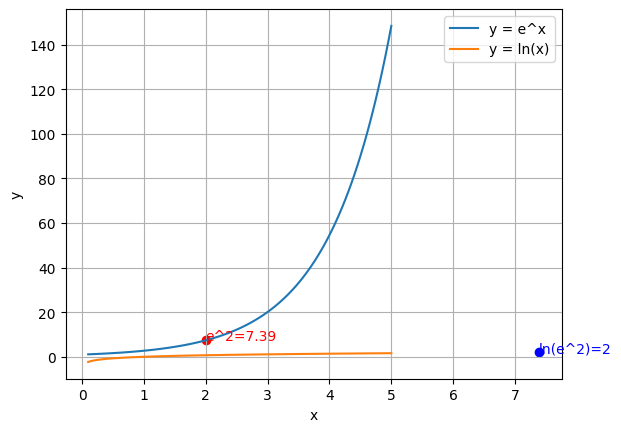

In [ ]:
# 지수와 로그그래프

import matplotlib.pyplot as plt
import numpy as np

# x 값 범위 설정
x_vals = np.linspace(0.1, 5, 100)   # 𝑥  값을 0.1부터 5까지 준비합니다.(로그는 0 이하에서 정의되지 않으므로 0.1부터 시작)

# 함수 정의
exp_vals = np.exp(x_vals)           # e^x    시간이 지날수록 값이 커지는 과정  = 지수함수
log_vals = np.log(x_vals)           # ln(x)  커진 값을 보고 걸린 시간을 되짚는 과정 = 로그함

# 그래프 그리기
plt.plot(x_vals, exp_vals, label="y = e^x")
plt.plot(x_vals, log_vals, label="y = ln(x)")

# 점 표시 예시
x_point = 2
plt.scatter([x_point], [np.exp(x_point)], color='red')   #  e^2 ≈ 7.39     시간 2 → 양 7.39
plt.text(x_point, np.exp(x_point), f"e^{x_point}={np.exp(x_point):.2f}", color='red')

plt.scatter([np.exp(x_point)], [np.log(np.exp(x_point))], color='blue') # # ln(e^2) = 2  math.log(7.39) → 2   / 양 7.39 → 시간 2
plt.text(np.exp(x_point), np.log(np.exp(x_point)), f"ln(e^{x_point})={x_point}", color='blue')

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 지수 함수  : 시간을 넣으면 커진 양을 알려줌   e^2 ≈ 7.39     시간 2 → 양 7.39
# 로그 함수  : 커진 양을 넣으면 걸린 시간을 알려줌  math.log(7.39) → 2   / 양 7.39 → 시간 2
# 그래프 전체 의미: 두 함수가 서로 반대 개념이라는 것을 시각적으로 확인할 수 있음


---

In [ ]:
# 3. 딥러닝과 연결
# 설명: 손실 함수(loss)를 최소화하는 과정이 결국 경사하강법
# 코드 예제(간단한 손실 함수 흉내):


import numpy as np   #  라이브러리를 호

# 딥러닝에서 학습되는 값은 가중치(weight)인데, 여기서는 w=5에서 시작한다고 가정
w = 5.0
learning_rate = 0.1  # 한 번에 얼마나 고칠지(학습 속도)를 정하는 값

# 손실 함수: (w-3)^2
def loss(w):
    return (w-3)**2   # 정답은 w=3일 때 손실이 0   / w가 3에 가까워질수록 손실이 줄어듭니다.

def dloss(w):
    return 2*(w-3)   # 손실 함수의 미분(기울기)  - 현재 w가 정답보다 얼마나 큰지/작은지를 알려주는 값

for i in range(20):
    w = w - learning_rate*dloss(w)
    print(f"반복 {i+1}: w={w:.4f}, loss={loss(w):.4f}")
    # w = w - learning_rate*dloss(w) → 경사하강법 공식
    # 현재 위치에서 기울기를 계산하고  그 방향으로 조금 이동해서  손실을 줄여갑니다.
# 👉 출력: w가 점점 3에 가까워지고, loss가 줄어듦

반복 1: w=4.6000, loss=2.5600
반복 2: w=4.2800, loss=1.6384
반복 3: w=4.0240, loss=1.0486
반복 4: w=3.8192, loss=0.6711
반복 5: w=3.6554, loss=0.4295
반복 6: w=3.5243, loss=0.2749
반복 7: w=3.4194, loss=0.1759
반복 8: w=3.3355, loss=0.1126
반복 9: w=3.2684, loss=0.0721
반복 10: w=3.2147, loss=0.0461
반복 11: w=3.1718, loss=0.0295
반복 12: w=3.1374, loss=0.0189
반복 13: w=3.1100, loss=0.0121
반복 14: w=3.0880, loss=0.0077
반복 15: w=3.0704, loss=0.0050
반복 16: w=3.0563, loss=0.0032
반복 17: w=3.0450, loss=0.0020
반복 18: w=3.0360, loss=0.0013
반복 19: w=3.0288, loss=0.0008
반복 20: w=3.0231, loss=0.0005


📌 코드 흐름을 짚어보면:  


- **손실 함수(loss)**: `(w-3)^2` → 최적의 가중치 \(w=3\)일 때 최소화됨.  
  - 여기서 `loss(w)`는 “정답에서 얼마나 벗어났는지”를 나타내는 점수예요.  

- **미분(gradient)**: `dloss(w) = 2*(w-3)` → 현재 위치에서 기울기를 계산.  
  - 정답은 `w=3`이고, 멀리 떨어질수록 점수가 커집니다.  
  - `dloss(w)`는 “지금 위치에서 어느 방향으로 움직여야 점수가 줄어드는지”를 알려주는 기울기입니다.  

- **업데이트 규칙**: `w = w - learning_rate * dloss(w)` → 기울기 방향으로 조금씩 이동.  
- 반복할수록 `w`가 3에 가까워지고, `loss` 값이 줄어듦 → 경사하강법의 핵심 원리.  




📊 출력 해석:  
- 처음엔 `w=5`에서 시작 → `loss=4`  
- 반복할수록 `w`가 3에 가까워지고, `loss`가 0에 수렴  
- 딥러닝에서는 이 과정을 수천, 수만 번 반복하면서 **가중치 최적화**를 수행합니다.  

즉, 지금 예시는 **“딥러닝에서 손실 함수를 최소화하는 과정이 결국 경사하강법이다”**라는 설명과 정확히 맞아떨어집니다.  

👉 패턴적으로도 앞에서 했던 “비유 → 수학적 개념 → 코드 → 결과 해석” 흐름과 잘 이어지고 있어요.  
- 미분: 기울기 계산  
- 경사하강법: 기울기를 따라 내려가기  
- 딥러닝 연결: 손실 함수를 최소화하는 과정  


### 💡 확인 문제: 3. 자연상수 $e$와 로그 ($\ln$)

Q1. 수학자들은 미분해도 자기 자신으로 남아 계산이 매우 깔끔한 특별한 수인 자연상수 \[ ]와 그를 밑으로 하는 지수함수($e^x$)를 딥러닝에 활용합니다.

Q2. 딥러닝에서 자연로그(ln)는 너무 커지는 오차 값을 작게 압축하여 계산 안정성과 효율성을 높이는 데 기여한다. (O/X)

Q3. 은행 예금의 복리 성장처럼 '시간이 지나면서 커지는 양'을 표현하는 함수가 지수함수 $e^x$라면, '커진 양을 보고 그 크기에 도달하기까지 걸린 시간'을 알려주는 함수는 무엇일까요?

Q4. 만약 어떤 값이 $e^4 \approx 54.6$이라고 할 때, 자연로그를 이용하여 이 값에 도달하는 데 걸린 '시간' 또는 '횟수'를 표현하면 얼마가 될까요? (즉, $\ln(e^4)$ 값은?)




<br/><br/><br/>
✅ 정답

Q1. e

Q2. O

Q3. 자연로그 ($\ln x$)

Q4. $\ln(e^4) = 4$입니다.

---